# Prediksi Harga rumah menggunakan model extreme gradient boosting (xgboost) dan optimasi menggunakan: optuna hyperparameter optimization

&emsp; Rumah merupakan kebutuhan primer yang permintaannya terus meningkat sejalan dengan meningkatnya jumlah populasi penduduk Indonesia, terkait hal tersebut masyarakat memerlukan informasi mengenai harga wajar suatu rumah. Harga suatu rumah dapat dinilai pada posisi harga wajar, overvalued, atau undervalued menggunakan beberapa parameter seperti lokasi, luas bangunan, luas tanah, jumlah kamar mandi, jumlah kamar tidur, dan garasi. Penelitian ini bertujuan untuk melakukan optimasi xgboost dalam memprediksi harga rumah dengan menggunakan optuna hyperparameter optimization.

Pada penelitian ini menggunakan CRISP-DM (Cross-Industry Standard Process for Data Mining) yang meliputi:
- Business Understanding
- Data Understanding
- Data Preparation
- Modeling
- Evaluation
- Deployment

In [123]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [124]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from tqdm import tqdm
import optuna
import time
import re

## Akuisisi Data

In [125]:
df = pd.read_csv('data/Raw-Final-Rumah.csv')
df

,Harga,Kamar Tidur,Kamar Mandi,Garasi,Luas Tanah,Luas Bangunan,Kecamatan,Page
0,"2,5 Miliar",4,3,10,LT : 438 m²,LB : 110 m²,Tapos,129
1,385 Juta,3,2,1,LT : 50 m²,LB : 60 m²,Pancoran Mas,129
2,385 Juta,3,2,1,LT : 50 m²,LB : 60 m²,Cipayung,129
3,385 Juta,3,2,1,LT : 50 m²,LB : 60 m²,Rangkapanjaya,129
4,385 Juta,3,2,1,LT : 50 m²,LB : 60 m²,Pancoran Mas,129
...,...,...,...,...,...,...,...,...
40195,756 Juta Total,LT:168 m²,NaN,NaN,NaN,NaN,Cilodong,910
40196,"3,9 Miliar",4,2,2,LT : 375 m²,LB : 221 m²,Cinere,910
40197,7 Miliar,5,4,1,LT : 500 m²,LB : 568 m²,Cinere,910
40198,"8,5 Miliar",5,5,2,LT : 770 m²,LB : 345 m²,Cinere,910


## Data Understanding

In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40200 entries, 0 to 40199
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Harga          40200 non-null  str  
 1   Kamar Tidur    40191 non-null  str  
 2   Kamar Mandi    35797 non-null  str  
 3   Garasi         35011 non-null  str  
 4   Luas Tanah     32501 non-null  str  
 5   Luas Bangunan  24598 non-null  str  
 6   Kecamatan      40200 non-null  str  
 7   Page           40200 non-null  int64
dtypes: int64(1), str(7)
memory usage: 2.5 MB


In [127]:
df.isnull().sum()

Harga                0
Kamar Tidur          9
Kamar Mandi       4403
Garasi            5189
Luas Tanah        7699
Luas Bangunan    15602
Kecamatan            0
Page                 0
dtype: int64

## Data Preparation

### Parsing Harga

In [128]:
def parse_harga(h):
    if pd.isna(h):
        return None
    h = str(h).replace(',', '.').strip()
    
    match = re.search(r'[\d.]+', h)
    if not match:
        return None
    
    angka = float(match.group())
    
    if 'miliar' in h.lower():
        return angka * 1_000_000_000
    elif 'juta' in h.lower():
        return angka * 1_000_000
    
    return angka

df['Harga'] = df['Harga'].apply(parse_harga)
df['Harga'] = pd.to_numeric(df['Harga'], errors='coerce').astype('Float64')

### Konversi Tipedata

In [129]:
df['Kamar Tidur'] = pd.to_numeric(df['Kamar Tidur'], errors='coerce').astype('Int64')
df['Kamar Mandi'] = pd.to_numeric(df['Kamar Mandi'], errors='coerce').astype('Int64')
df['Garasi']      = pd.to_numeric(df['Garasi'], errors='coerce').fillna(0).astype('Int64')

def parse_luas(x):
    match = re.search(r'[\d.]+', str(x))
    return float(match.group()) if match else None

df['Luas Tanah']    = df['Luas Tanah'].apply(parse_luas).astype('Float64')
df['Luas Bangunan'] = df['Luas Bangunan'].apply(parse_luas).astype('Float64')

c:\Users\EAGLEONE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:19:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\EAGLEONE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:19:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


=== Feature Importance — SEMUA Fitur (Sebelum Drop) ===
      Feature  Importance        Tipe
Luas Bangunan    0.500426     Numerik
   Luas Tanah    0.229347     Numerik
         Page    0.126482     Numerik
  Kamar Mandi    0.064236     Numerik
    Kecamatan    0.037263 Kategorical
       Garasi    0.024696     Numerik
  Kamar Tidur    0.017549     Numerik

Fitur dengan importance < 5% : ['Kecamatan', 'Garasi', 'Kamar Tidur']
Fitur dengan importance >= 5% : ['Luas Bangunan', 'Luas Tanah', 'Page', 'Kamar Mandi']


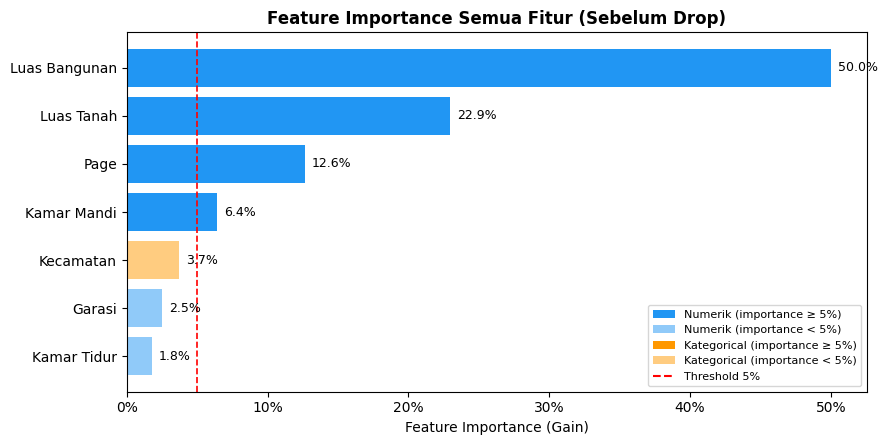


Catatan:
  • Fitur BIRU/ORANYE GELAP (≥ 5%) → berpengaruh signifikan, pertahankan.
  • Fitur BIRU/ORANYE MUDA  (< 5%) → kontribusi kecil, kandidat drop.
  • Kecamatan (kategorical) di-encode sementara hanya untuk analisis ini.


In [130]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import RobustScaler, LabelEncoder

# ── 1. Kumpulkan SEMUA fitur kandidat (sebelum drop apapun) ─────────────
_num_cols = ['Kamar Tidur', 'Kamar Mandi', 'Garasi', 'Luas Tanah', 'Luas Bangunan']
_cat_cols = []

# Sertakan 'Lokasi' jika ada (hasil rename dari Kecamatan)
if 'Kecamatan' in df.columns:
    _cat_cols.append('Kecamatan')

# Sertakan 'Page' jika ada
if 'Page' in df.columns:
    _num_cols_extra = ['Page']
else:
    _num_cols_extra = []

_all_feature_cols = _num_cols + _num_cols_extra + _cat_cols
_target = 'Harga'

# ── 2. Siapkan dataframe sementara ──────────────────────────────────────
_df_fi = df[_all_feature_cols + [_target]].copy()
_df_fi = _df_fi.replace([np.inf, -np.inf], np.nan)

# Label encode kolom kategorical agar bisa masuk XGBoost
_le_map = {}
for col in _cat_cols:
    _df_fi[col] = _df_fi[col].astype(str).str.strip().str.lower()
    _le = LabelEncoder()
    _df_fi[col] = _le.fit_transform(_df_fi[col].fillna('unknown'))
    _le_map[col] = _le

_df_fi = _df_fi.dropna()

_X_fi = _df_fi[_all_feature_cols].astype(float)
_y_fi = np.log1p(_df_fi[_target].astype(float))

# ── 3. Scale & latih model sementara ───────────────────────────────────
_sc_fi   = RobustScaler()
_X_fi_sc = _sc_fi.fit_transform(_X_fi)

_fi_model = XGBRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=42, tree_method='hist', device='cuda'
)
_fi_model.fit(_X_fi_sc, _y_fi)

# ── 4. Susun tabel importance ───────────────────────────────────────────
_fi_df = (
    pd.DataFrame({'Feature': _all_feature_cols,
                  'Importance': _fi_model.feature_importances_,
                  'Tipe': ['Kategorical' if c in _cat_cols else 'Numerik'
                           for c in _all_feature_cols]})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print("=== Feature Importance — SEMUA Fitur (Sebelum Drop) ===")
print(_fi_df.to_string(index=False))
print(f"\nFitur dengan importance < 5% : {_fi_df[_fi_df['Importance'] < 0.05]['Feature'].tolist()}")
print(f"Fitur dengan importance >= 5% : {_fi_df[_fi_df['Importance'] >= 0.05]['Feature'].tolist()}")

# ── 5. Visualisasi ──────────────────────────────────────────────────────
_color_map = {
    'Numerik':     {'high': '#2196F3', 'low': '#90CAF9'},
    'Kategorical': {'high': '#FF9800', 'low': '#FFCC80'},
}
_colors = [
    _color_map[row['Tipe']]['high'] if row['Importance'] >= 0.05
    else _color_map[row['Tipe']]['low']
    for _, row in _fi_df[::-1].iterrows()
]

fig, ax = plt.subplots(figsize=(9, max(4, len(_all_feature_cols) * 0.65)))
bars = ax.barh(_fi_df['Feature'][::-1], _fi_df['Importance'][::-1],
               color=_colors, edgecolor='none')

for bar, val in zip(bars, _fi_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}', va='center', ha='left', fontsize=9)

ax.axvline(0.05, color='red', linestyle='--', linewidth=1.2, label='Threshold 5%')
ax.set_xlabel('Feature Importance (Gain)', fontsize=10)
ax.set_title('Feature Importance Semua Fitur (Sebelum Drop)', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Legend tipe fitur
from matplotlib.patches import Patch
_legend_handles = [
    Patch(facecolor='#2196F3', label='Numerik (importance ≥ 5%)'),
    Patch(facecolor='#90CAF9', label='Numerik (importance < 5%)'),
    Patch(facecolor='#FF9800', label='Kategorical (importance ≥ 5%)'),
    Patch(facecolor='#FFCC80', label='Kategorical (importance < 5%)'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='Threshold 5%'),
]
ax.legend(handles=_legend_handles, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

print("\nCatatan:")
print("  • Fitur BIRU/ORANYE GELAP (≥ 5%) → berpengaruh signifikan, pertahankan.")
print("  • Fitur BIRU/ORANYE MUDA  (< 5%) → kontribusi kecil, kandidat drop.")
print("  • Kecamatan (kategorical) di-encode sementara hanya untuk analisis ini.")


### Rename & Drop

In [131]:
df = df.rename(columns={'Kecamatan': 'Lokasi'})
df = df.drop(columns=['Page'], errors='ignore')
df = df.drop(columns=['Lokasi'], errors='ignore')

### FINAL CLEANING

In [132]:
# Hapus NaN & infinite
df = df.replace([np.inf, -np.inf], np.nan)

# Drop baris yang masih bermasalah
df = df.dropna(subset=[
    'Harga', 'Kamar Tidur', 'Kamar Mandi', 
    'Garasi', 'Luas Tanah', 'Luas Bangunan'
])

In [133]:
df

,Harga,Kamar Tidur,Kamar Mandi,Garasi,Luas Tanah,Luas Bangunan
0,2500000000.0,4,3,10,438.0,110.0
1,385000000.0,3,2,1,50.0,60.0
2,385000000.0,3,2,1,50.0,60.0
3,385000000.0,3,2,1,50.0,60.0
4,385000000.0,3,2,1,50.0,60.0
...,...,...,...,...,...,...
40189,1000000000.0,3,3,2,119.0,200.0
40193,1670000000.0,2,2,1,78.0,106.0
40196,3900000000.0,4,2,2,375.0,221.0
40197,7000000000.0,5,4,1,500.0,568.0


### Hapus outlier

In [134]:
features = ['Kamar Tidur', 'Kamar Mandi', 'Garasi', 'Luas Tanah', 'Luas Bangunan']
target   = 'Harga'

df_clean = df.copy()

# Hapus outlier dengan IQR per kolom numerik
for col in features + [target]:
    Q1, Q3 = df_clean[col].quantile([0.05, 0.95])
    df_clean = df_clean[(df_clean[col] >= Q1) & (df_clean[col] <= Q3)]

print(f"Baris setelah filter outlier: {len(df_clean):,}")

X = df_clean[features].copy()
y = df_clean[target].copy()

Baris setelah filter outlier: 16,674


In [135]:
df.isnull().sum()

Harga            0
Kamar Tidur      0
Kamar Mandi      0
Garasi           0
Luas Tanah       0
Luas Bangunan    0
dtype: int64

### Train-test split DULU

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training: {len(X_train):,} | Test: {len(X_test):,}')

Training: 13,339 | Test: 3,335


### Log transform target

In [137]:
y_train_log = np.log1p(y_train)   # log1p aman untuk nilai 0
# y_test TIDAK ditransformasi → dipakai asli untuk evaluasi

### Scale fitur (fit dari train saja)

In [138]:
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## Modeling

### Fungsi metrik (dengan inverse log transform)

In [139]:
def regression_metrics(y_true, y_pred_log):
    """y_pred_log adalah output model (dalam skala log); y_true dalam skala asli."""
    y_pred = np.expm1(y_pred_log)          # inverse dari log1p
    y_pred = np.clip(y_pred, 0, None)      # hindari nilai negatif

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, mape, r2

### Baseline 

In [140]:
base_model = XGBRegressor(random_state=42, tree_method='hist', device='cuda')

start = time.time()
base_model.fit(X_train_sc, y_train_log)
baseline_time = time.time() - start

y_pred_base = base_model.predict(X_test_sc)
baseline_metrics = regression_metrics(y_test, y_pred_base)
print(f"Baseline R²: {baseline_metrics[3]:.4f} | MAPE: {baseline_metrics[2]:.2f}%")

Baseline R²: 0.8204 | MAPE: 16.77%


c:\Users\EAGLEONE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:19:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\EAGLEONE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:19:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


### Optuna HPO (konsisten: semua pakai X_train_sc + y_train_log)

In [141]:
%pip install ipywidgets jupyterlab_widgets

Note: you may need to restart the kernel to use updated packages.


In [142]:
pbar = tqdm(total=300, desc="Optuna")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({"best": f"{-study.best_value:.4f}"})


Optuna:  19%|█▉        | 58/300 [03:00<12:34,  3.12s/it, best=0.2356]


In [143]:
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 20),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'random_state'     : 42,
        'tree_method'      : 'hist',
        'device'           : 'cuda',
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(
        model, X_train_sc, y_train_log,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=1
    )
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

start = time.time()
study.optimize(objective, n_trials=300, callbacks=[tqdm_callback])
optuna_time = time.time() - start
pbar.close()

c:\Users\EAGLEONE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:19:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\EAGLEONE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:19:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\EAGLEONE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:19:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\EAGLEONE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: User

In [144]:
y_test_log = np.log1p(y_test)

best_model = XGBRegressor(
    **study.best_params,
    random_state=42,
    tree_method='hist',
    device='cuda',
    early_stopping_rounds=20,
    eval_metric='rmse'
)
best_model.fit(
    X_train_sc,
    y_train_log,
    eval_set=[(X_test_sc, y_test_log)],
    verbose=False
)

y_pred_optuna = best_model.predict(X_test_sc)
optuna_metrics = regression_metrics(y_test, y_pred_optuna)

c:\Users\EAGLEONE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\callback.py:385: UserWarning: [06:27:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
c:\Users\EAGLEONE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\callback.py:385: UserWarning: [06:27:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


In [145]:
results = pd.DataFrame({
    'Method'  : ['Baseline', 'Optuna'],
    'RMSE'    : [baseline_metrics[0], optuna_metrics[0]],
    'MAE'     : [baseline_metrics[1], optuna_metrics[1]],
    'MAPE (%)'  : [baseline_metrics[2], optuna_metrics[2]],
    'R²'      : [baseline_metrics[3], optuna_metrics[3]],
    'Time (s)': [baseline_time, optuna_time],
})
print(results.to_string(index=False))

  Method         RMSE          MAE  MAPE (%)       R²   Time (s)
Baseline 3.062577e+08 2.013948e+08 16.766359 0.820409   0.051871
  Optuna 2.967282e+08 1.922679e+08 16.137857 0.831412 506.001046


In [146]:
def predict_harga(kamar_tidur, kamar_mandi, garasi, luas_tanah, luas_bangunan):
    X_new = np.array([[kamar_tidur, kamar_mandi, garasi, luas_tanah, luas_bangunan]])
    X_new_sc = scaler.transform(X_new)
    y_log = best_model.predict(X_new_sc)
    return np.expm1(y_log)[0]

In [147]:
harga = predict_harga(3, 2, 1, 100, 120)
print(f"\nPrediksi: Rp {harga:,.0f}")


Prediksi: Rp 1,606,630,272


c:\Users\EAGLEONE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


In [148]:
import pickle
import json
from datetime import datetime

# ─── Save ───────────────────────────────────────────────────────────
# 1. Model
with open('tuning_v1.1-copy/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# 2. Scaler
with open('tuning_v1.1-copy/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Metadata
metadata = {
    "saved_at"      : datetime.now().isoformat(),
    "features"      : features,
    "target"        : target,
    "n_train"       : len(X_train),
    "n_test"        : len(X_test),
    "best_params"   : study.best_params,
    "metrics": {
        "rmse" : optuna_metrics[0],
        "mae"  : optuna_metrics[1],
        "mape" : optuna_metrics[2],
        "r2"   : optuna_metrics[3],
    }
}

with open('tuning_v1.1-copy/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved: tuning_v1.1-copy/model.pkl | tuning_v1.1-copy/scaler.pkl | tuning_v1.1-copy/metadata.json")

Saved: tuning_v1.1-copy/model.pkl | tuning_v1.1-copy/scaler.pkl | tuning_v1.1-copy/metadata.json


In [149]:
y_pred_final = np.expm1(best_model.predict(X_test_sc))

# Cek distribusi error
residuals = y_test.values - y_pred_final
pct_error = (residuals / y_test.values) * 100

print("=== Distribusi Error ===")
print(f"Error < 10% : {(np.abs(pct_error) < 10).mean()*100:.1f}% prediksi")
print(f"Error < 20% : {(np.abs(pct_error) < 20).mean()*100:.1f}% prediksi")
print(f"Error < 30% : {(np.abs(pct_error) < 30).mean()*100:.1f}% prediksi")
print(f"Error > 50% : {(np.abs(pct_error) > 50).mean()*100:.1f}% prediksi ← bahaya")


=== Distribusi Error ===
Error < 10% : 48.0% prediksi
Error < 20% : 73.5% prediksi
Error < 30% : 86.1% prediksi
Error > 50% : 4.7% prediksi ← bahaya


In [150]:
bins = pd.qcut(y_test, q=4, labels=['Murah','Menengah','Mahal','Mewah'])
df_eval = pd.DataFrame({
    'actual'   : y_test.values,
    'predicted': y_pred_final,
    'mape'     : np.abs(pct_error),
    'segment'  : bins.values
})

print("\n=== MAPE per Segmen Harga ===")
print(df_eval.groupby('segment')['mape'].agg(['mean','median','max']).round(2))


=== MAPE per Segmen Harga ===
           mean  median     max
segment                        
Murah     19.34   11.19  229.94
Menengah   17.7   10.98   194.0
Mahal     13.23    9.51    81.5
Mewah     14.27   11.07   58.55


In [151]:
import matplotlib.pyplot as plt

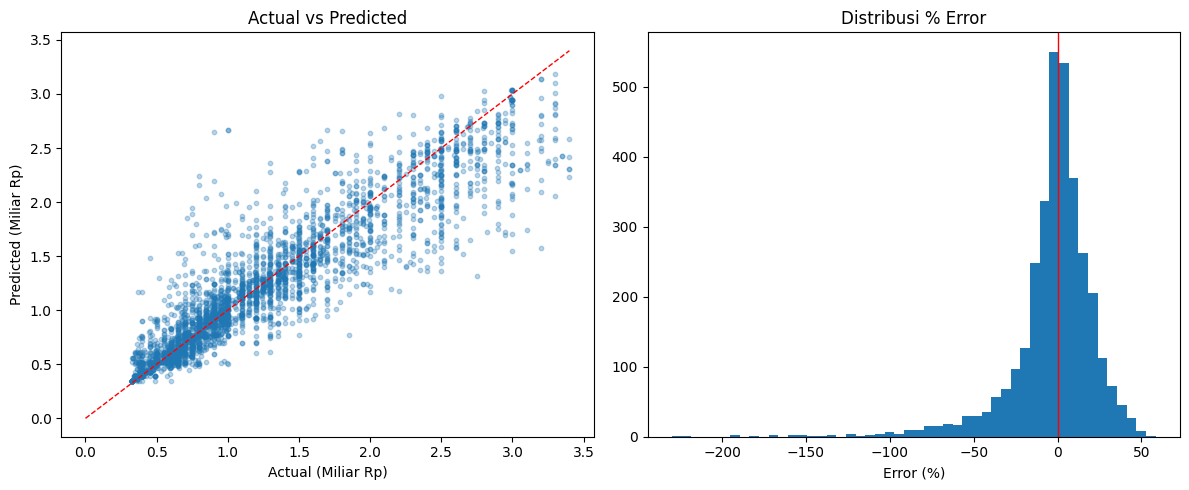

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test/1e9, y_pred_final/1e9, alpha=0.3, s=10)
lim = max(y_test.max(), y_pred_final.max()) / 1e9
axes[0].plot([0, lim], [0, lim], 'r--', lw=1)
axes[0].set_xlabel('Actual (Miliar Rp)')
axes[0].set_ylabel('Predicted (Miliar Rp)')
axes[0].set_title('Actual vs Predicted')

axes[1].hist(pct_error, bins=50, edgecolor='none')
axes[1].axvline(0, color='red', lw=1)
axes[1].set_xlabel('Error (%)')
axes[1].set_title('Distribusi % Error')

plt.tight_layout()
plt.show()

In [153]:
y_pred_train = np.expm1(best_model.predict(X_train_sc))
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_final)

print(f"\n=== Overfitting Check ===")
print(f"R² Train : {r2_train:.4f}")
print(f"R² Test  : {r2_test:.4f}")
print(f"Gap      : {r2_train - r2_test:.4f}", end="  ")
print("✓ OK" if r2_train - r2_test < 0.05 else "⚠ Overfit")


=== Overfitting Check ===
R² Train : 0.8938
R² Test  : 0.8314
Gap      : 0.0624  ⚠ Overfit


In [154]:
print(f'Training: {len(X_train):,} | Test: {len(X_test):,}')

Training: 13,339 | Test: 3,335


In [155]:
print(f"Total data clean: {len(df_clean):,}")
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# Cek distribusi harga
print(f"\nHarga min : Rp {y.min():,.0f}")
print(f"Harga max : Rp {y.max():,.0f}")
print(f"Harga mean: Rp {y.mean():,.0f}")
print(f"Harga median: Rp {y.median():,.0f}")

# cek distribusi kamar tidur
print("\nDistribusi Kamar Tidur:")
print(f"Kamar Tidur min: {df['Kamar Tidur'].min()}")
print(f"Kamar Tidur max: {df['Kamar Tidur'].max()}")
print(f"Kamar Tidur mean: {df['Kamar Tidur'].mean():.2f}")
print(f"Kamar Tidur median: {df['Kamar Tidur'].median()}")

# cek distribusi kamar mandi
print("\nDistribusi Kamar Mandi:")
print(f"Kamar Mandi min: {df['Kamar Mandi'].min()}")
print(f"Kamar Mandi max: {df['Kamar Mandi'].max()}")
print(f"Kamar Mandi mean: {df['Kamar Mandi'].mean():.2f}")
print(f"Kamar Mandi median: {df['Kamar Mandi'].median()}")

# cek distribusi garasi
print("\nDistribusi Garasi:")
print(f"Garasi min: {df['Garasi'].min()}")
print(f"Garasi max: {df['Garasi'].max()}")
print(f"Garasi mean: {df['Garasi'].mean():.2f}")
print(f"Garasi median: {df['Garasi'].median()}")

# cek distribusi luas tanah
print("\nDistribusi Luas Tanah:")
print(f"Luas Tanah min: {df['Luas Tanah'].min()}")
print(f"Luas Tanah max: {df['Luas Tanah'].max()}")
print(f"Luas Tanah mean: {df['Luas Tanah'].mean():.2f}")
print(f"Luas Tanah median: {df['Luas Tanah'].median()}")


# cek distribusi luas bangunan
print("\nDistribusi Luas Bangunan:")
print(f"Luas Bangunan min: {df['Luas Bangunan'].min()}")
print(f"Luas Bangunan max: {df['Luas Bangunan'].max()}")
print(f"Luas Bangunan mean: {df['Luas Bangunan'].mean():.2f}")
print(f"Luas Bangunan median: {df['Luas Bangunan'].median()}")

Total data clean: 16,674
Train: 13,339 | Test: 3,335

Harga min : Rp 330,000,000
Harga max : Rp 3,400,000,000
Harga mean: Rp 1,268,659,950
Harga median: Rp 1,100,000,000

Distribusi Kamar Tidur:
Kamar Tidur min: 1
Kamar Tidur max: 284
Kamar Tidur mean: 3.51
Kamar Tidur median: 3.0

Distribusi Kamar Mandi:
Kamar Mandi min: 1
Kamar Mandi max: 180
Kamar Mandi mean: 2.66
Kamar Mandi median: 2.0

Distribusi Garasi:
Garasi min: 1
Garasi max: 30
Garasi mean: 1.59
Garasi median: 1.0

Distribusi Luas Tanah:
Luas Tanah min: 1.0
Luas Tanah max: 200250.0
Luas Tanah mean: 197.03
Luas Tanah median: 96.0

Distribusi Luas Bangunan:
Luas Bangunan min: 1.0
Luas Bangunan max: 100000000.0
Luas Bangunan mean: 4244.15
Luas Bangunan median: 100.0
